In [1]:
import pandas as pd
import allel
import seaborn as sns

In [2]:
cam5_annot = pd.read_csv('cam5_annot.csv')

In [3]:
clim1001 = pd.read_csv('../key_files/1001g_regmap_grenet_ecotype_info_corrected_bioclim_2024May16.csv')

clim1001['ecotypeid'] = clim1001['ecotypeid'].astype(str)

ecotypeid_to_bio1 = clim1001.set_index('ecotypeid')['bio1'].to_dict()

In [5]:
import subprocess

command = """
grep "^#" ../gwas/1001g/1001g_grenet_climate.recode.vcf > filtered_cam5_1001g.vcf && \
grep "^2\s" ../gwas/1001g/1001g_grenet_climate.recode.vcf | \
awk '$2 >= 11531967 && $2 <= 11534358' >> filtered_cam5_1001g.vcf
"""

# Run the command in a bash shell
subprocess.run(command, shell=True, executable='/bin/bash')

CompletedProcess(args='\ngrep "^#" ../gwas/1001g/1001g_grenet_climate.recode.vcf > filtered_cam5_1001g.vcf && grep "^2\\s" ../gwas/1001g/1001g_grenet_climate.recode.vcf | awk \'$2 >= 11531967 && $2 <= 11534358\' >> filtered_cam5_1001g.vcf\n', returncode=0)

In [12]:
command = """
zgrep "^#" ../gwas/greneNet_final_v1.1.recode.vcf.gz> filtered_cam5_grenenet.vcf && \
zgrep "^2\s" ../gwas/greneNet_final_v1.1.recode.vcf.gz | \
awk '$2 >= 11531967 && $2 <= 11534358' >> filtered_cam5_grenenet.vcf
"""

# Run the command in a bash shell
subprocess.run(command, shell=True, executable='/bin/bash')

CompletedProcess(args='\nzgrep "^#" ../gwas/greneNet_final_v1.1.recode.vcf.gz> filtered_cam5_grenenet.vcf && zgrep "^2\\s" ../gwas/greneNet_final_v1.1.recode.vcf.gz | awk \'$2 >= 11531967 && $2 <= 11534358\' >> filtered_cam5_grenenet.vcf\n', returncode=0)

In [ ]:
# Convert start and end into an IntervalIndex
exons_utr_df['interval'] = pd.IntervalIndex.from_arrays(exons_utr_df['start'], exons_utr_df['end'], closed='both')

# Set the IntervalIndex as the index of the DataFrame
exons_utr_df.set_index('interval', inplace=True)

In [ ]:
vcf1001 = allel.read_vcf('filtered_cam5_1001g.vcf')

geno = vcf1001['calldata/GT']

geno = geno.sum(axis=2)

geno = pd.DataFrame(geno)

geno.columns = vcf1001['samples']

g1001_chrom_pos = pd.DataFrame({'chrom': vcf1001['variants/CHROM'], 'pos': vcf1001['variants/POS']})

vcf1001 = pd.concat([g1001_chrom_pos, geno],axis=1)

vcf_1001_cam5annot = cam5_annot.merge(vcf1001, on = 'pos')

vcf_1001_cam5annot = vcf_1001_cam5annot.drop('chrom_x',axis=1)

bios_maped = vcf_1001_cam5annot.columns[5:].map(ecotypeid_to_bio1)

new_columns = ['pos', 'EFF', 'LOF', 'NMD', 'chrom_y'] + bios_maped.tolist()

vcf_1001_cam5annot.columns = new_columns

eff_columns = vcf_1001_cam5annot['EFF'].str.split('|', expand=True)

eff_columns.columns = ['Effect', 'Impact', 'Position', 'Change', 'Gene', 'Biotype', 'Rank', 'HGVS.c', 'HGVS.p', 'cdna_pos', 'Other']

eff_columns = eff_columns.drop(['Position', 'Change', 'Gene', 'Biotype', 'cdna_pos', 'Other'],axis=1)

vcf_1001_cam5annot = pd.concat([eff_columns, vcf_1001_cam5annot],axis=1)





In [196]:
vcf_1001_cam5annot.loc[(vcf_1001_cam5annot['pos']>= 11533904) & (vcf_1001_cam5annot['pos']<= 11534263), 'block'] = 'sign_block'

In [197]:
vcf_1001_cam5annot[(vcf_1001_cam5annot['pos']>= 11532004) & (vcf_1001_cam5annot['pos']<= 11532068)]

,Effect,Impact,Rank,HGVS.c,HGVS.p,pos,EFF,LOF,NMD,chrom_y,...,8.88749980926514,8.21666622161865,9.11666679382324,15.8291664123535,15.1000003814697,18.3333339691162,13.2791662216187,8.71666717529297,9.88749980926514,block
0,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.1,11532055,5_prime_UTR_variant(MODIFIER||14|c.-14A>C|149|...,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,NaN


In [198]:


exons_utr_df_var1 = exons_utr_df[exons_utr_df['annotation'] == 'Parent=AT2G27030.1']
# Map each SNP position to its corresponding feature type
vcf_1001_cam5annot['feature_type_var1'] = vcf_1001_cam5annot['pos'].apply(
    lambda x: exons_utr_df_var1.loc[exons_utr_df_var1.index.contains(x)]['feature_type'].values[0] if any(exons_utr_df_var1.index.contains(x)) else 'intergenic'
)

exons_utr_df_var2 = exons_utr_df[exons_utr_df['annotation'] == 'Parent=AT2G27030.2']
# Map each SNP position to its corresponding feature type
vcf_1001_cam5annot['feature_type_var2'] = vcf_1001_cam5annot['pos'].apply(
    lambda x: exons_utr_df_var2.loc[exons_utr_df_var2.index.contains(x)]['feature_type'].values[0] if any(exons_utr_df_var2.index.contains(x)) else 'intergenic'
)

exons_utr_df_var3 = exons_utr_df[exons_utr_df['annotation'] == 'Parent=AT2G27030.3']
# Map each SNP position to its corresponding feature type
vcf_1001_cam5annot['feature_type_var3'] = vcf_1001_cam5annot['pos'].apply(
    lambda x: exons_utr_df_var3.loc[exons_utr_df_var3.index.contains(x)]['feature_type'].values[0] if any(exons_utr_df_var3.index.contains(x)) else 'intergenic'
)

# Display the updated DataFrame


In [199]:
vcf_1001_cam5annot.columns

Index([           'Effect',            'Impact',              'Rank',
                  'HGVS.c',            'HGVS.p',               'pos',
                     'EFF',               'LOF',               'NMD',
                 'chrom_y',
       ...
          15.8291664123535,    15.1000003814697,    18.3333339691162,
          13.2791662216187,    8.71666717529297,    9.88749980926514,
                   'block', 'feature_type_var1', 'feature_type_var2',
       'feature_type_var3'],
      dtype='object', length=1151)

In [203]:
vcf_1001_cam5annot['Effect'].unique()

array(['5_prime_UTR_variant(MODIFIER',
       '5_prime_UTR_premature_start_codon_gain_variant(LOW',
       'synonymous_variant(LOW', '3_prime_UTR_variant(MODIFIER',
       'missense_variant(MODERATE', 'upstream_gene_variant(MODIFIER'],
      dtype=object)

In [204]:
for_hm

Effect,5_prime_UTR_variant(MODIFIER,5_prime_UTR_variant(MODIFIER,5_prime_UTR_variant(MODIFIER,5_prime_UTR_variant(MODIFIER,5_prime_UTR_variant(MODIFIER,5_prime_UTR_premature_start_codon_gain_variant(LOW,5_prime_UTR_variant(MODIFIER,5_prime_UTR_premature_start_codon_gain_variant(LOW,5_prime_UTR_premature_start_codon_gain_variant(LOW,5_prime_UTR_variant(MODIFIER,...,missense_variant(MODERATE,missense_variant(MODERATE,synonymous_variant(LOW,synonymous_variant(LOW,missense_variant(MODERATE,3_prime_UTR_variant(MODIFIER,3_prime_UTR_variant(MODIFIER,3_prime_UTR_variant(MODIFIER,3_prime_UTR_variant(MODIFIER,upstream_gene_variant(MODIFIER
8.87916660308838,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10.3583335876465,0,2,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9.86666679382324,2,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
11.3208332061768,0,2,0,0,0,0,0,2,2,0,...,0,0,2,0,0,0,0,0,0,0
2.70000004768372,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18.3333339691162,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
13.2791662216187,0,2,0,0,0,0,0,0,0,0,...,2,2,2,0,2,0,2,2,0,0
8.71666717529297,0,2,0,0,0,0,0,0,0,0,...,2,2,2,0,2,0,2,2,0,0
9.88749980926514,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [239]:
vcf_1001_cam5annot['Impact'].unique()

array(['', 'SILENT', 'MISSENSE'], dtype=object)

In [241]:
vcf_1001_cam5annot[vcf_1001_cam5annot['Impact'] != '']

,Effect,Impact,Rank,HGVS.c,HGVS.p,pos,EFF,LOF,NMD,chrom_y,...,15.8291664123535,15.1000003814697,18.3333339691162,13.2791662216187,8.71666717529297,9.88749980926514,block,feature_type_var1,feature_type_var2,feature_type_var3
42,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.2,11532790,synonymous_variant(LOW|SILENT|ggT/ggG|p.Gly24G...,NaN,NaN,2,...,0,2,0,0,0,0,NaN,exon,exon,exon
43,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.2,11532868,synonymous_variant(LOW|SILENT|ctC/ctG|p.Leu50L...,NaN,NaN,2,...,0,0,2,0,2,0,NaN,exon,exon,exon
44,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.2,11532919,synonymous_variant(LOW|SILENT|gcA/gcT|p.Ala67A...,NaN,NaN,2,...,2,0,0,0,2,0,NaN,exon,exon,exon
76,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.3,11534092,synonymous_variant(LOW|SILENT|agA/agG|p.Arg154...,NaN,NaN,2,...,0,0,0,0,0,0,sign_block,intergenic,exon,exon
77,missense_variant(MODERATE,MISSENSE,protein_coding,CODING,AT2G27030.3,11534094,missense_variant(MODERATE|MISSENSE|gTt/gCt|p.V...,NaN,NaN,2,...,2,0,0,2,2,0,sign_block,intergenic,exon,exon
78,missense_variant(MODERATE,MISSENSE,protein_coding,CODING,AT2G27030.3,11534099,missense_variant(MODERATE|MISSENSE|Gca/Aca|p.A...,NaN,NaN,2,...,2,0,0,2,2,0,sign_block,intergenic,exon,exon
79,missense_variant(MODERATE,MISSENSE,protein_coding,CODING,AT2G27030.3,11534102,missense_variant(MODERATE|MISSENSE|Gca/Aca|p.A...,NaN,NaN,2,...,2,0,0,2,2,0,sign_block,intergenic,exon,exon
80,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.3,11534143,synonymous_variant(LOW|SILENT|aaT/aaC|p.Asn171...,NaN,NaN,2,...,2,0,0,2,2,0,sign_block,intergenic,exon,exon
81,synonymous_variant(LOW,SILENT,protein_coding,CODING,AT2G27030.3,11534161,synonymous_variant(LOW|SILENT|caC/caT|p.His177...,NaN,NaN,2,...,0,0,0,0,0,0,sign_block,intergenic,exon,exon
82,missense_variant(MODERATE,MISSENSE,protein_coding,CODING,AT2G27030.3,11534165,missense_variant(MODERATE|MISSENSE|Cgt/Tgt|p.A...,NaN,NaN,2,...,2,0,0,2,2,0,sign_block,intergenic,exon,exon


In [244]:
vcf_1001_cam5annot = vcf_1001_cam5annot[vcf_1001_cam5annot['block'] == 'sign_block']

In [250]:
for_hm

,-11.49,-11.49,-4.28,-3.27,-3.00,-2.87,-2.49,-1.93,-1.18,0.72,...,17.15,17.17,17.18,17.23,17.70,17.75,17.84,18.33,18.59,22.70
Impact,,,,,,,,,,,,,,,,,,,,,
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,2,0,0,2
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,2,0,0,2
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,2,0,0,0
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,2,0,0,2
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,2,0,0,2
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,2,0,0,2
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,2,0,0,2


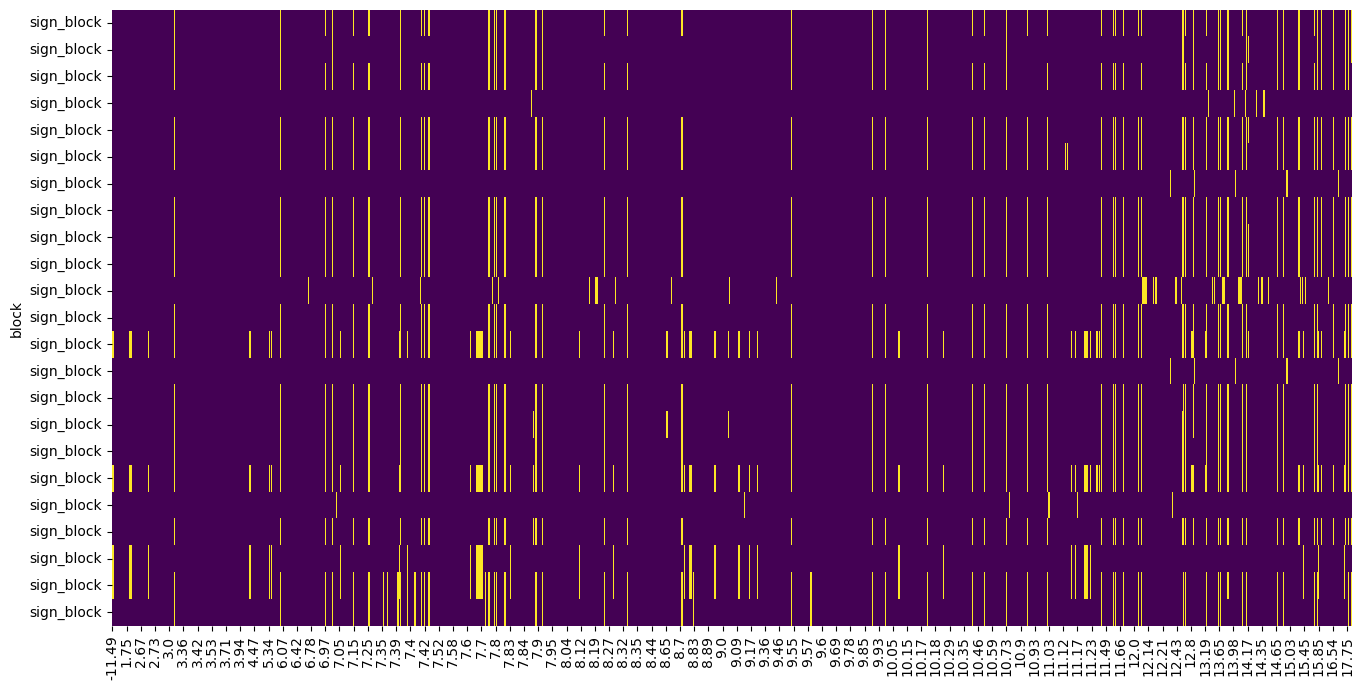

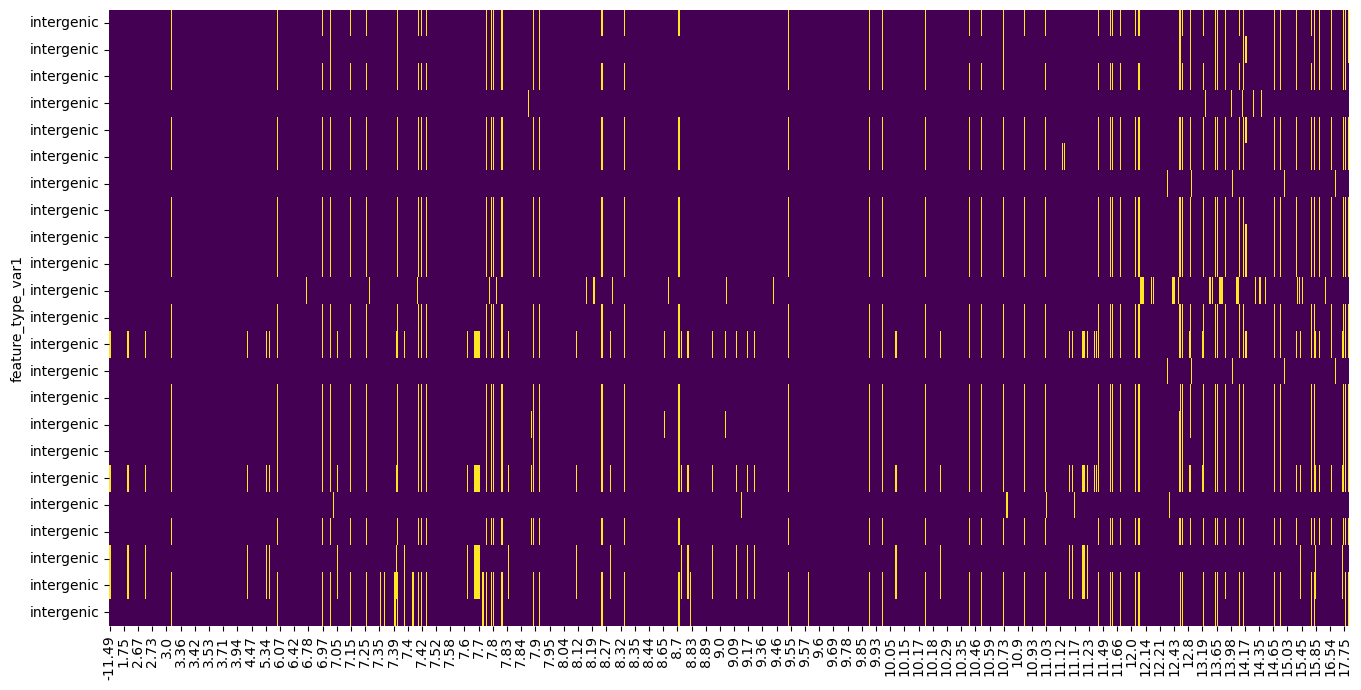

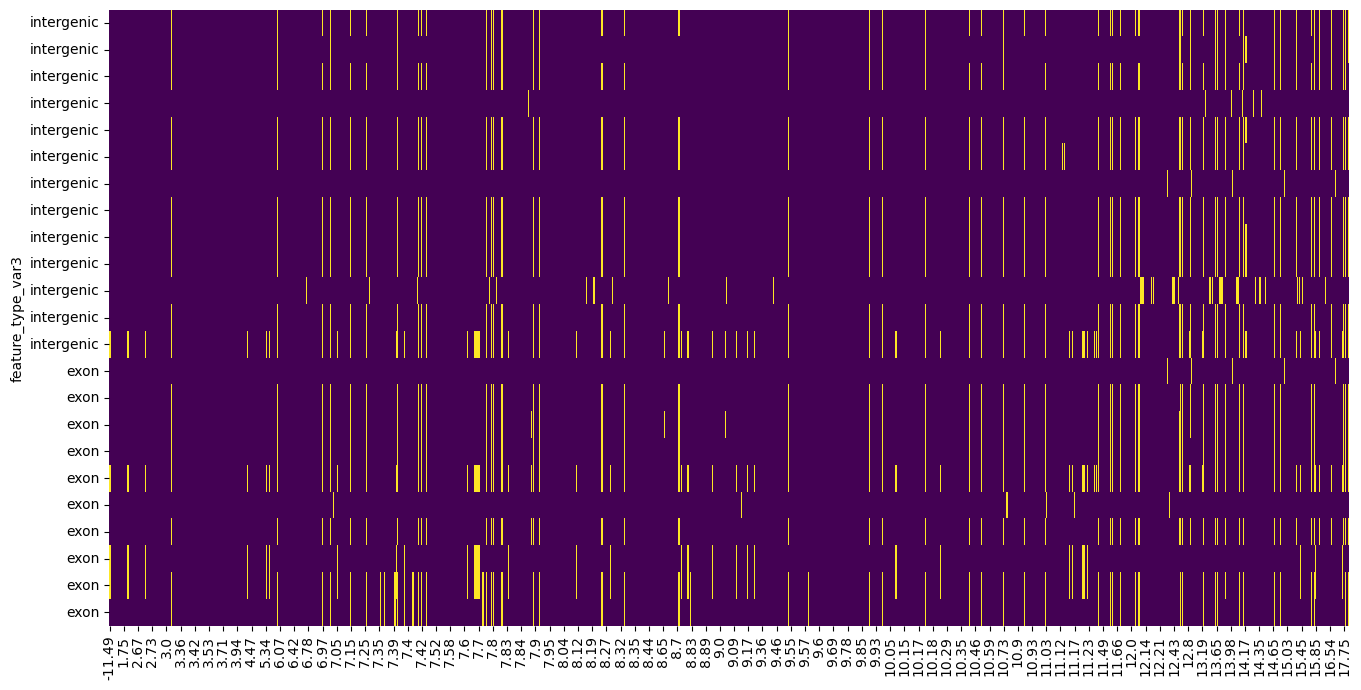

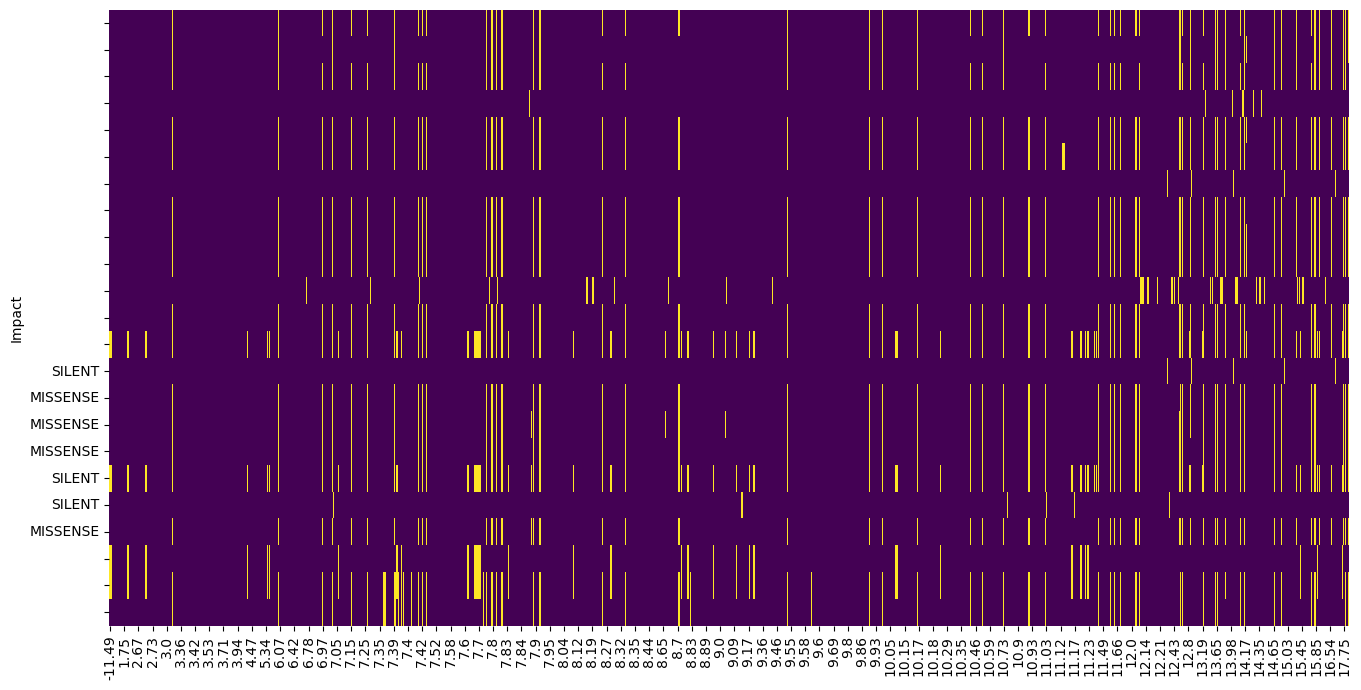

In [253]:
for i in [ 'block', 'feature_type_var1', 'feature_type_var3', 'Impact', ]:  # 'LOF',  'NMD''EFF',  'pos', 'HGVS.c',  'HGVS.p',  'Rank',  'feature_type_var2' 'Effect'
    for_hm = vcf_1001_cam5annot.copy()
    for_hm = for_hm.set_index(i)

    for_hm = for_hm.iloc[:, 10:-4]
    
    for_hm = for_hm.T
    
    for_hm = for_hm.sort_index()
    
    for_hm.index = np.round(for_hm.index.astype(float),2)

    for_hm = for_hm.T

    # Create the heatmap
    plt.figure(figsize=(16, 8))  # Increase the figure size to make the heatmap bigger
    heatmap_plot = sns.heatmap(for_hm, cmap="viridis", cbar=False)
    #plt.savefig(f'heaatmap_1001_g__block{i}.png')
    # Show the plot
    plt.show()

In [235]:
for_hm.

,-11.49,-11.49,-4.28,-3.27,-3.00,-2.87,-2.49,-1.93,-1.18,0.72,...,17.15,17.17,17.18,17.23,17.70,17.75,17.84,18.33,18.59,22.70
Impact,,,,,,,,,,,,,,,,,,,,,
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
,0,0,2,0,0,0,2,0,0,0,...,0,2,2,0,0,0,0,0,2,2
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,2,2,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0
,2,2,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,2,0,0,2
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,2


In [216]:
indexes = ['block', 'feature_type_var1', 'feature_type_var3', 'Impact']
for_hm = vcf_1001_cam5annot.set_index(indexes)

In [219]:
for_hm = for_hm.iloc[:, 9:-1].T 

In [225]:
indexes = ['block', 'feature_type_var1', 'feature_type_var3', 'Impact']
for_hm = vcf_1001_cam5annot.set_index(indexes)

# Slice and transpose the DataFrame
for_hm = for_hm.iloc[:, 9:-1].T

In [227]:
# Round the index values
for_hm.index = np.round(for_hm.index.astype(float), 2)

In [229]:
for_hm = for_hm.T

In [232]:
for_hm

9.17   8.88   10.36  \
block      feature_type_var1 feature_type_var3 Impact                        
NaN        exon              exon                          0      0      0   
           intergenic        intergenic                    2      2      2   
                                                           0      0      0   
                                                           0      0      2   
                                                           0      0      0   
...                                                      ...    ...    ...   
sign_block intergenic        exon                          0      0      0   
                                                           0      0      0   
                                                           0      0      0   
NaN        intergenic        exon                          0      0      0   
                             intergenic                    0      0      0   

                                                       9.87   11.32  2.70   \
block      feature_type_var1 feature_type_var3 Impact                        
NaN        exon              exon                          2      0      0   
           intergenic        intergenic                    2      2      0   
                                                           0      0      0   
                                                           0      0      0   
                                                           0      0      0   
...                                                      ...    ...    ...   
sign_block intergenic        exon                          0      0      0   
                                                           0      0      0   
                                                           0      0      0   
NaN        intergenic        exon                          0      0      0   
                             intergenic                    2      0      0   

                                                       2.70   2.70   7.70   \
block      feature_type_var1 feature_type_var3 Impact                        
NaN        exon              exon                          0      0      0   
           intergenic        intergenic                    0      0      0   
                                                           0      0      0   
                                                           0      0      0   
                                                           0      0      0   
...                                                      ...    ...    ...   
sign_block intergenic        exon                          0      2      2   
                                                           0      2      2   
                                                           0      0      0   
NaN        intergenic        exon                          0      0      0   
                             intergenic                    0      0      0   

                                                       13.72  ...  8.29   \
block      feature_type_var1 feature_type_var3 Impact         ...          
NaN        exon              exon                          0  ...      0   
           intergenic        intergenic                    0  ...      2   
                                                           0  ...      0   
                                                           0  ...      0   
                                                           0  ...      0   
...                                                      ...  ...    ...   
sign_block intergenic        exon                          0  ...      0   
                                                           0  ...      0   
                                                           0  ...      0   
NaN        intergenic        exon                          0  ...      0   
                             intergenic                    0  ...      0   

                     

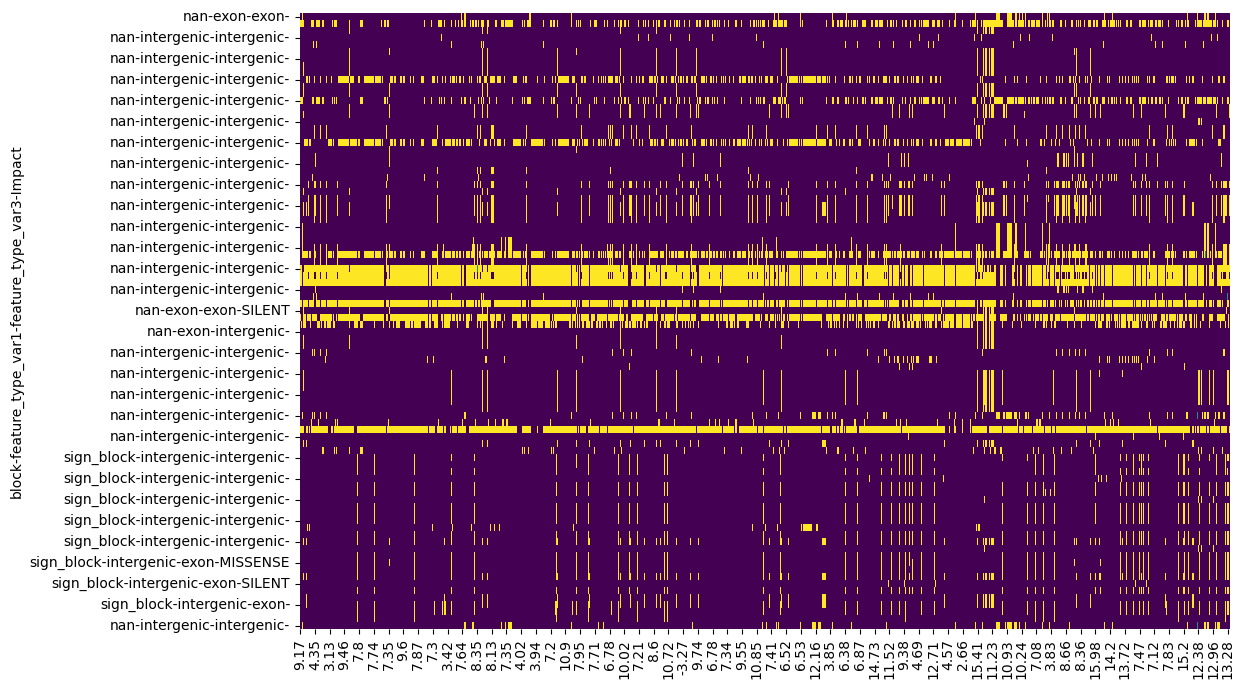

In [231]:
plt.figure(figsize=(12, 8))  # Increase the figure size to make the heatmap bigger
heatmap_plot = sns.heatmap(for_hm, cmap="viridis", cbar=False)

# Show the plot
plt.show()

In [617]:
vcfgrene = allel.read_vcf('filtered_cam5_grenenet.vcf')

geno = vcfgrene['calldata/GT']

geno = geno.sum(axis=2)

geno = pd.DataFrame(geno)

geno.columns = vcfgrene['samples']

grene_chrom_pos = pd.DataFrame({'chrom': vcfgrene['variants/CHROM'], 'pos': vcfgrene['variants/POS']})

vcfgrene = pd.concat([grene_chrom_pos, geno],axis=1)

In [618]:
vcf_grene_cam5annot = cam5_annot.merge(vcfgrene, on = 'pos')

vcf_grene_cam5annot = vcf_grene_cam5annot.drop('chrom_x',axis=1)

#bios_maped = vcf_grene_cam5annot.columns[5:].map(ecotypeid_to_bio1)

#new_columns = ['pos', 'EFF', 'LOF', 'NMD', 'chrom_y'] + bios_maped.tolist()

#vcf_grene_cam5annot.columns = new_columns

eff_columns = vcf_grene_cam5annot['EFF'].str.split('|', expand=True)

eff_columns.columns = ['Effect', 'Impact', 'Position', 'Change', 'Gene', 'Biotype', 'Rank', 'HGVS.c', 'HGVS.p', 'cdna_pos', 'Other']

eff_columns = eff_columns.drop(['Position', 'Change', 'Gene', 'Biotype', 'cdna_pos', 'Other'],axis=1)

vcf_grene_cam5annot = pd.concat([eff_columns, vcf_grene_cam5annot],axis=1)





In [619]:
vcf_grene_cam5annot

,Effect,Impact,Rank,HGVS.c,HGVS.p,pos,EFF,LOF,NMD,chrom_y,...,9965,9966,9978,9985,100001,100002,6939,9940,9977,9992
0,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.1,11532055,5_prime_UTR_variant(MODIFIER||14|c.-14A>C|149|...,NaN,NaN,2,...,0,0,0,2,0,0,0,0,0,0
1,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532148,5_prime_UTR_variant(MODIFIER||571|c.-571C>A|11...,NaN,NaN,2,...,2,2,2,2,0,0,0,2,0,0
2,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532152,5_prime_UTR_variant(MODIFIER||567|c.-567T>C|11...,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
3,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532162,5_prime_UTR_variant(MODIFIER||557|c.-557C>T|11...,NaN,NaN,2,...,0,0,0,0,0,0,0,2,0,0
4,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532176,5_prime_UTR_variant(MODIFIER||543|c.-543A>G|11...,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11534224,3_prime_UTR_variant(MODIFIER||1164|c.*1164C>T|...,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
84,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11534244,3_prime_UTR_variant(MODIFIER||1184|c.*1184T>A|...,NaN,NaN,2,...,0,0,2,0,2,0,0,0,0,0
85,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11534263,3_prime_UTR_variant(MODIFIER||1203|c.*1203T>C|...,NaN,NaN,2,...,0,0,2,0,2,0,0,2,0,0
86,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.3,11534313,3_prime_UTR_variant(MODIFIER||137|c.*137T>G|18...,NaN,NaN,2,...,0,0,0,0,2,0,0,0,0,0


In [620]:
exons_utr_df_var1 = exons_utr_df[exons_utr_df['annotation'] == 'Parent=AT2G27030.1']
# Map each SNP position to its corresponding feature type
vcf_grene_cam5annot['feature_type_var1'] = vcf_grene_cam5annot['pos'].apply(
    lambda x: exons_utr_df_var1.loc[exons_utr_df_var1.index.contains(x)]['feature_type'].values[0] if any(exons_utr_df_var1.index.contains(x)) else 'intergenic'
)

exons_utr_df_var2 = exons_utr_df[exons_utr_df['annotation'] == 'Parent=AT2G27030.2']
# Map each SNP position to its corresponding feature type
vcf_grene_cam5annot['feature_type_var2'] = vcf_grene_cam5annot['pos'].apply(
    lambda x: exons_utr_df_var2.loc[exons_utr_df_var2.index.contains(x)]['feature_type'].values[0] if any(exons_utr_df_var2.index.contains(x)) else 'intergenic'
)

exons_utr_df_var3 = exons_utr_df[exons_utr_df['annotation'] == 'Parent=AT2G27030.3']
# Map each SNP position to its corresponding feature type
vcf_grene_cam5annot['feature_type_var3'] = vcf_grene_cam5annot['pos'].apply(
    lambda x: exons_utr_df_var3.loc[exons_utr_df_var3.index.contains(x)]['feature_type'].values[0] if any(exons_utr_df_var3.index.contains(x)) else 'intergenic'
)

In [621]:
vcf_grene_cam5annot

,Effect,Impact,Rank,HGVS.c,HGVS.p,pos,EFF,LOF,NMD,chrom_y,...,9985,100001,100002,6939,9940,9977,9992,feature_type_var1,feature_type_var2,feature_type_var3
0,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.1,11532055,5_prime_UTR_variant(MODIFIER||14|c.-14A>C|149|...,NaN,NaN,2,...,2,0,0,0,0,0,0,exon,exon,exon
1,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532148,5_prime_UTR_variant(MODIFIER||571|c.-571C>A|11...,NaN,NaN,2,...,2,0,0,0,2,0,0,intergenic,exon,intergenic
2,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532152,5_prime_UTR_variant(MODIFIER||567|c.-567T>C|11...,NaN,NaN,2,...,0,0,0,0,0,0,0,intergenic,exon,intergenic
3,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532162,5_prime_UTR_variant(MODIFIER||557|c.-557C>T|11...,NaN,NaN,2,...,0,0,0,0,2,0,0,intergenic,exon,intergenic
4,5_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11532176,5_prime_UTR_variant(MODIFIER||543|c.-543A>G|11...,NaN,NaN,2,...,0,0,0,0,0,0,0,intergenic,exon,intergenic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11534224,3_prime_UTR_variant(MODIFIER||1164|c.*1164C>T|...,NaN,NaN,2,...,0,0,0,0,0,0,0,intergenic,exon,exon
84,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11534244,3_prime_UTR_variant(MODIFIER||1184|c.*1184T>A|...,NaN,NaN,2,...,0,2,0,0,0,0,0,intergenic,exon,exon
85,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.2,11534263,3_prime_UTR_variant(MODIFIER||1203|c.*1203T>C|...,NaN,NaN,2,...,0,2,0,0,2,0,0,intergenic,exon,exon
86,3_prime_UTR_variant(MODIFIER,,protein_coding,CODING,AT2G27030.3,11534313,3_prime_UTR_variant(MODIFIER||137|c.*137T>G|18...,NaN,NaN,2,...,0,2,0,0,0,0,0,intergenic,intergenic,exon


In [622]:
for_hm = vcf_grene_cam5annot.set_index('feature_type_var3')

In [623]:
for_hm = for_hm.iloc[:, 10:-4].T

In [624]:
for_hm

feature_type_var3,exon,intergenic,intergenic,intergenic,intergenic,intergenic,intergenic,intergenic,intergenic,intergenic,...,exon,exon,exon,exon,exon,exon,exon,exon,exon,intergenic
10002,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10006,0,2,0,0,0,0,0,2,2,0,...,0,0,2,0,0,0,0,0,0,0
10011,0,0,0,0,0,0,0,0,0,2,...,0,0,2,0,0,2,2,0,0,0
10013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10014,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9985,2,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
100001,0,0,0,0,0,0,0,0,0,0,...,2,2,2,0,2,0,2,2,2,0
100002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6939,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0


In [625]:
for_hm = for_hm.sort_index()
for_hm = for_hm.T

In [712]:
for_hm_exon = for_hm.tail(20)

In [713]:
for_hm_exon = for_hm_exon.loc['exon', :]

In [716]:
for_hm_exon

,100001,100002,10002,10006,10011,10013,10014,159,265,5151,...,9925,9933,9940,9941,9944,9947,9965,9966,9978,9985
feature_type_var3,,,,,,,,,,,,,,,,,,,,,
exon,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
exon,2,0,0,0,0,0,0,0,0,0,...,0,0,2,0,2,0,0,0,2,0
exon,2,0,0,0,0,0,0,0,0,0,...,0,0,2,0,2,0,0,0,2,0
exon,2,0,0,0,0,0,0,0,0,0,...,0,0,2,0,2,0,0,0,2,0
exon,2,0,0,2,2,0,0,0,0,0,...,0,0,0,0,2,0,0,0,2,0
exon,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
exon,2,0,0,0,0,0,0,0,0,0,...,0,0,2,0,2,0,0,0,2,0
exon,0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
exon,2,0,0,0,2,0,0,0,0,0,...,0,0,0,0,2,0,0,0,2,0


In [714]:
pseudo_prs_exon3 = for_hm_exon.sum(axis=0).reset_index()

In [715]:
pseudo_prs_exon3

,index,0
0,100001,16
1,100002,0
2,10002,0
3,10006,2
4,10011,6
...,...,...
224,9947,2
225,9965,2
226,9966,0
227,9978,14


In [629]:
pseudo_prs_exon3.shape

(229, 2)

In [631]:
pseudo_prs_exon3 = pseudo_prs_exon3.merge(clim1001[['ecotypeid', 'bio1']], left_on ='index', right_on = 'ecotypeid', how = 'left')

In [633]:
pseudo_prs_exon3.to_csv('pseudo_prs_exon3_grenenet.csv',index=None)

In [592]:
clim1001

,Unnamed: 0,ecotypeid,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,...,vapr03,vapr04,vapr05,vapr06,vapr07,vapr08,vapr09,vapr10,vapr11,vapr12
0,1,159,9.325000,7.700000,32.352940,596.430664,22.700001,-1.100000,23.800001,3.216667,...,0.69,0.77,1.05,1.28,1.44,1.45,1.28,1.05,0.77,0.66
1,2,265,12.962500,9.558333,42.293510,483.411774,25.200001,2.600000,22.600000,8.000000,...,0.96,1.01,1.30,1.55,1.82,1.80,1.62,1.34,1.02,0.92
2,3,763,-2.995833,13.675000,29.728262,1198.782471,19.900000,-26.100000,46.000000,8.016666,...,0.25,0.43,0.59,0.73,0.77,0.68,0.49,0.38,0.24,0.15
3,4,765,-2.487500,14.675000,30.829832,1216.552734,21.299999,-26.299999,47.599998,3.550000,...,0.25,0.44,0.61,0.75,0.78,0.68,0.48,0.39,0.24,0.15
4,5,766,-4.283333,13.516666,32.648952,1032.257690,16.900000,-24.500000,41.400002,0.533333,...,0.18,0.35,0.49,0.62,0.65,0.56,0.39,0.31,0.18,0.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866,1867,9482,7.212500,7.408333,30.868055,627.401306,21.100000,-2.900000,24.000000,7.800000,...,0.55,0.67,0.92,1.18,1.43,1.41,1.16,0.91,0.71,0.60
1867,1868,9490,8.733334,7.150000,38.440861,425.015137,19.299999,0.700000,18.599998,12.066667,...,0.72,0.77,0.92,1.11,1.30,1.28,1.13,0.97,0.76,0.70
1868,1869,9496,8.662500,7.108334,38.423424,424.730530,19.200001,0.700000,18.500000,12.016666,...,0.71,0.77,0.92,1.12,1.30,1.28,1.12,0.97,0.76,0.69
1869,1870,9499,8.270833,6.975000,38.114754,422.419739,18.700001,0.400000,18.300001,8.733334,...,0.71,0.74,0.91,1.11,1.28,1.26,1.11,0.95,0.77,0.69


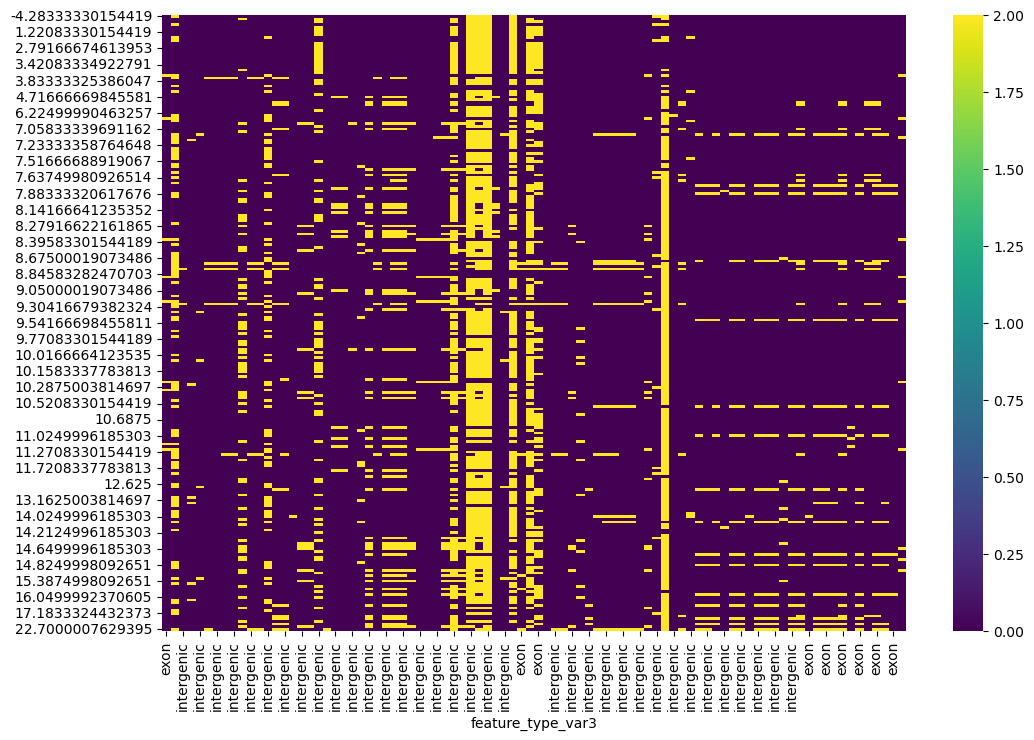

In [574]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `for_hm` is the dataframe you want to plot
plt.figure(figsize=(12, 8))  # Increase the figure size to make the heatmap bigger
sns.heatmap(for_hm, cmap="viridis")
plt.show()

In [562]:
for_hm

Impact,,,,,,,,,,,...,MISSENSE,MISSENSE,SILENT,SILENT,MISSENSE,,,,,
-4.283333,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
-3.270833,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
-2.995833,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
-2.487500,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
-1.929167,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17.695833,0,0,0,0,0,0,0,0,0,0,...,2,2,2,0,2,0,0,0,0,0
17.750000,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
17.837500,0,0,0,0,0,0,0,0,0,0,...,2,2,2,0,2,0,2,2,0,0
18.333334,0,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0


In [4]:
samples = pd.read_csv('../key_files/merged_sample_table.csv')[['site', 'plot', 'generation', 'total_flower_counts']]

samples = samples.groupby(['site', 'plot', 'generation'])['total_flower_counts'].sum().reset_index()

samples['min_perc'] = 1/samples['total_flower_counts']

samples['code'] = samples['site'].astype(str) + '_'  + samples['generation'].astype(str) + '_' + samples['plot'].astype(str) 

ecotype_freq = pd.read_csv('../key_files/merged_ecotype_frequency.txt',sep = '\t')

climate = pd.read_csv('../key_files/bioclimvars_experimental_sites_era5.csv')[['site', 'bio1']]

In [5]:
grenenet_ecotypes = pd.read_csv('../key_files/founder_ecotype_frequency.txt', sep = '\t',header=None)[0]

ecotype_freq = ecotype_freq.set_index(grenenet_ecotypes)

ecotype_freq = ecotype_freq.T 
ecotype_freq = ecotype_freq.reset_index()
ecotype_freq['generation'] = ecotype_freq['index'].str.split('_').str[1]

In [6]:
ecotype_freq['plot'] = ecotype_freq['index'].str.split('_').str[2]

ecotype_freq['site'] = ecotype_freq['index'].str.split('_').str[0] 

In [7]:
ecotype_freq = ecotype_freq.drop('index', axis=1)

In [8]:
ecotype_freq = ecotype_freq.melt(id_vars = ['plot','site', 'generation'])

In [9]:
ecotype_freq.columns = ['plot','site', 'generation', 'ecotype', 'freq']

In [10]:
clim1001f = clim1001[['ecotypeid', 'bio1']]

In [11]:
#clim1001f = clim1001f[clim1001f['bio1'] > 13]

In [12]:
clim1001f['ecotypeid'] = clim1001f['ecotypeid'].astype(int)

/tmp/ipykernel_1229368/3068168531.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clim1001f['ecotypeid'] = clim1001f['ecotypeid'].astype(int)


In [13]:
ecotype_freq = ecotype_freq.merge(clim1001f, left_on = 'ecotype', right_on = 'ecotypeid')

In [14]:
ecotype_freq['generation'] = ecotype_freq['generation'].astype(int)

In [19]:
import numpy as np

In [20]:
# Assuming df is your DataFrame named ecotype_freq
# Ensure that the DataFrame contains only the relevant generations
df = ecotype_freq[ecotype_freq['generation'].isin([1, 2, 3])]

# Function to check if frequency increases
def is_increasing(group):
    # Ensure the group is sorted by generation
    group = group.sort_values(by='generation')
    # Check if the last frequency is greater than the first, given there are at least two data points to compare
    if len(group['freq']) > 1:
        return group['freq'].iloc[-1] > group['freq'].iloc[0]
    else:
        return np.nan  # Return False if not enough data to compare

# Group by site, plot, and ecotype, then apply the function and reset index properly
result = df.groupby(['site', 'plot', 'ecotype']).apply(is_increasing).reset_index(name='increased')


In [21]:
#import os

In [22]:
#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')

In [23]:
clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/worldclim_sitesdata.csv')

In [24]:
clim_sites_during_exp = clim_sites_during_exp[['site', 'bio1']]

In [25]:
clim_sites_during_exp['site'] = clim_sites_during_exp['site'].astype(str)

In [26]:
result['increased'].value_counts()

increased
False    43045
True     14243
Name: count, dtype: int64

In [27]:
result = result.merge(clim_sites_during_exp, on ='site')

In [28]:
result

,site,plot,ecotype,increased,bio1
0,1,1,159,False,8.720833
1,1,1,265,True,8.720833
2,1,1,763,False,8.720833
3,1,1,765,False,8.720833
4,1,1,766,False,8.720833
...,...,...,...,...,...
82000,9,9,10011,False,10.116667
82001,9,9,10013,False,10.116667
82002,9,9,10014,False,10.116667
82003,9,9,100001,False,10.116667


In [29]:
result.columns = ['site', 'plot', 'ecotype', 'increased', 'bio1_exp']

In [30]:
result = result.merge(clim1001f, left_on = 'ecotype', right_on ='ecotypeid')

In [31]:
result = result.drop('ecotypeid',axis=1)

In [32]:
result.columns = ['site', 'plot', 'ecotype', 'increased', 'bio1_exp', 'bio1_ecotype']

In [33]:
result['bio1_exp'] = result['bio1_exp'].round(2)
result['bio1_ecotype'] = result['bio1_ecotype'].round(2)

In [34]:
bioexp_vs_bioecotype = result.pivot_table(index = 'bio1_exp', columns = 'bio1_ecotype', values= 'increased' )

In [35]:
bioexp_vs_bioecotype = bioexp_vs_bioecotype.sort_index() 

In [36]:
sorted_columns = sorted(bioexp_vs_bioecotype.columns)
bioexp_vs_bioecotype = bioexp_vs_bioecotype[sorted_columns]

In [37]:
clim1001f['bio1'] = clim1001f['bio1'].round(2)

/tmp/ipykernel_1229368/1059384320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clim1001f['bio1'] = clim1001f['bio1'].round(2)


In [38]:
clim1001f['ecotype_bio1'] = clim1001f['ecotypeid'].astype(str) + '_' + clim1001f['bio1'].astype(str)

/tmp/ipykernel_1229368/2563707021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clim1001f['ecotype_bio1'] = clim1001f['ecotypeid'].astype(str) + '_' + clim1001f['bio1'].astype(str)


In [39]:
clim1001f_dcit = clim1001f.set_index('bio1')['ecotype_bio1'].to_dict()

In [40]:
bioexp_vs_bioecotype.columns = bioexp_vs_bioecotype.columns.map(clim1001f_dcit)

In [41]:
clim_sites_during_exp['bio1'] = clim_sites_during_exp['bio1'].round(2)

In [42]:
clim_sites_during_exp['site_bio1'] = clim_sites_during_exp['site'].astype(str) + '_' + clim_sites_during_exp['bio1'].astype(str)

In [43]:
clim_sites_during_exp_dict = clim_sites_during_exp.set_index('bio1')['site_bio1'].to_dict()

In [44]:
bioexp_vs_bioecotype.index = bioexp_vs_bioecotype.index.map(clim_sites_during_exp_dict)

In [50]:
bioexp_vs_bioecotype = bioexp_vs_bioecotype.fillna(0)

In [51]:
bioexp_vs_bioecotype

bio1_ecotype,766_-4.28,7298_-3.27,763_-3.0,765_-2.49,9766_-1.93,768_0.72,9634_1.22,772_1.62,8354_1.88,9632_2.66,...,9879_16.59,9522_16.62,9726_17.17,9559_17.18,7067_17.23,7063_17.7,9657_17.75,9944_17.84,6939_18.33,6911_22.7
bio1_exp,,,,,,,,,,,,,,,,,,,,,
27_5.34,0.100000,0.300000,0.400000,0.200000,0.200000,0.100000,0.100000,0.200000,0.200000,0.200000,...,0.100000,0.300000,0.300000,0.200000,0.200000,0.100000,0.200000,0.300000,0.200000,0.300000
24_5.41,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000
48_7.33,0.000000,0.800000,0.200000,0.200000,0.200000,0.000000,0.000000,0.200000,0.200000,0.000000,...,0.600000,0.400000,0.200000,0.800000,0.600000,1.000000,0.200000,0.400000,0.800000,0.400000
25_7.9,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,...,0.083333,0.000000,0.000000,0.000000,0.083333,0.083333,0.000000,0.083333,0.083333,0.083333
42_8.34,0.000000,0.300000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.100000,...,0.400000,0.400000,0.200000,0.300000,0.200000,0.100000,0.200000,0.200000,0.200000,0.200000
1_8.72,0.083333,0.083333,0.083333,0.000000,0.000000,0.000000,0.083333,0.083333,0.083333,0.083333,...,0.000000,0.083333,0.083333,0.000000,0.083333,0.083333,0.083333,0.000000,0.000000,0.083333
55_8.93,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,...,0.200000,0.200000,0.100000,0.100000,0.000000,0.100000,0.100000,0.200000,0.100000,0.100000
52_9.27,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,...,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
49_9.39,0.363636,0.272727,0.363636,0.272727,0.363636,0.181818,0.181818,0.363636,0.181818,0.181818,...,0.000000,0.090909,0.000000,0.000000,0.363636,0.000000,0.000000,0.000000,0.181818,0.000000


In [46]:
bioexp_vs_bioecotype = bioexp_vs_bioecotype.T

In [47]:
bioexp_vs_bioecotype = bioexp_vs_bioecotype.T

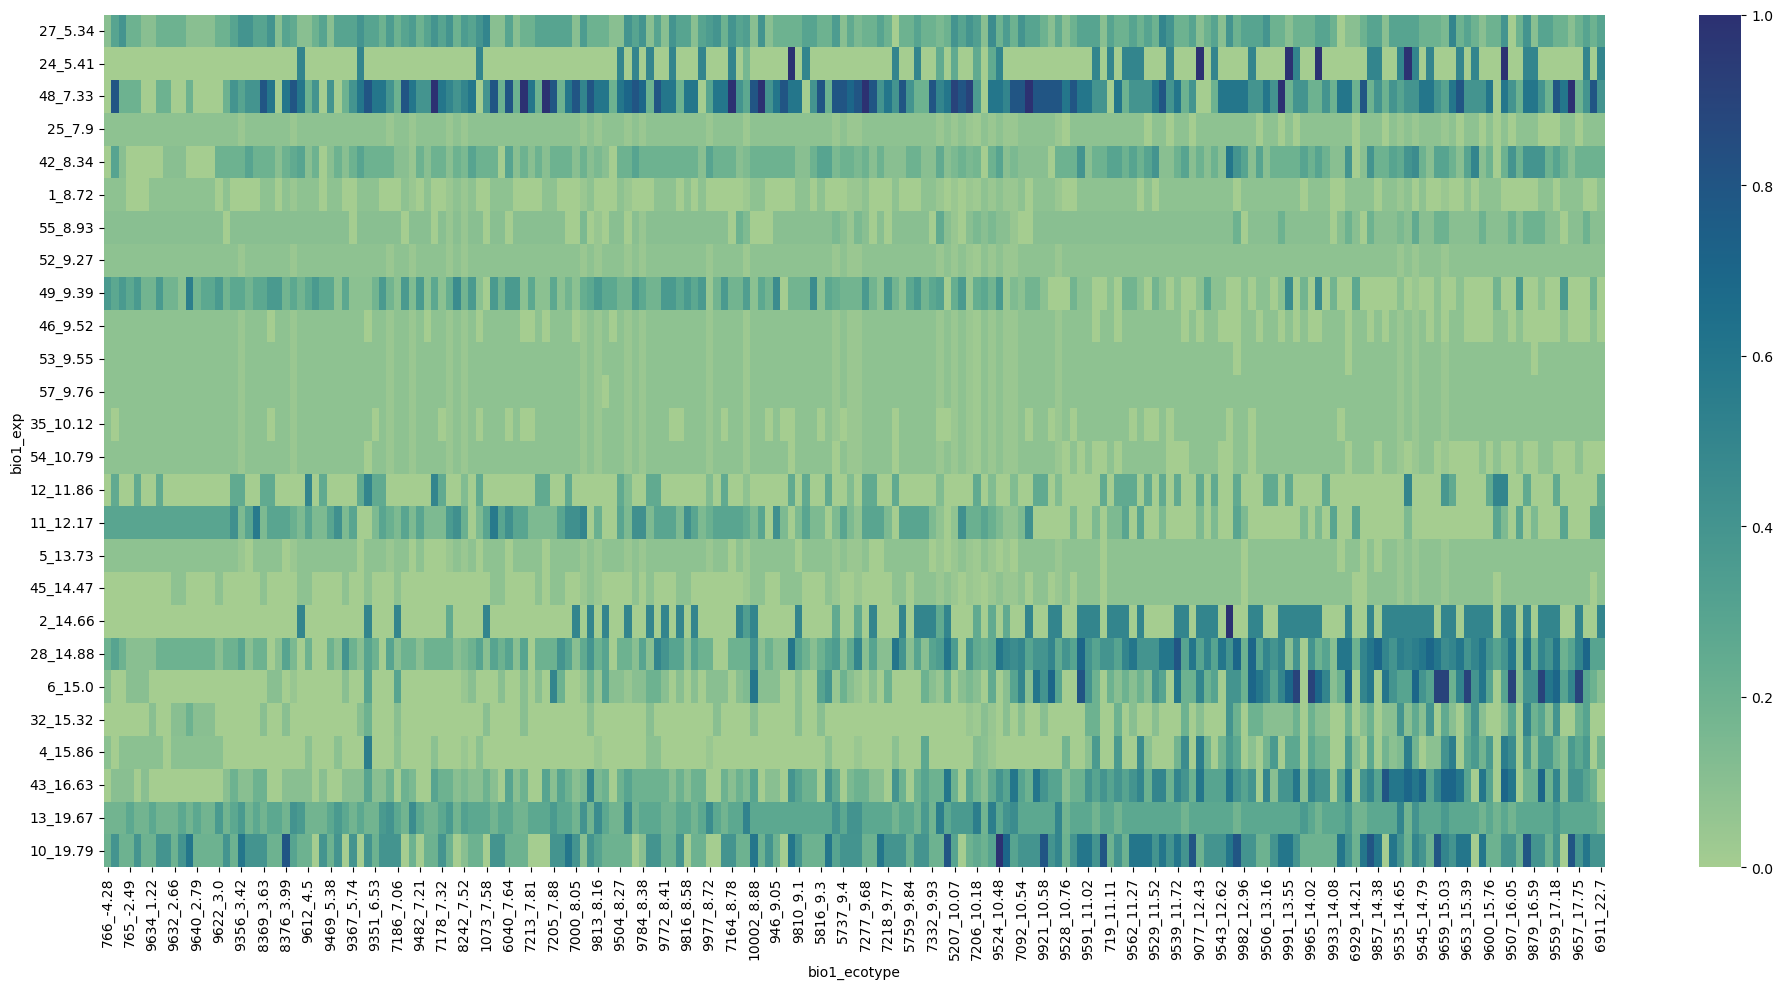

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming bioexp_vs_bioecotype is your DataFrame
plt.figure(figsize=(20, 10))  # Set the size of the figure

# Create the heatmap with a horizontal color bar at the top
ax = sns.heatmap(bioexp_vs_bioecotype, cmap="crest") # cbar_kws={'orientation': 'horizontal', 'label': 'Color scale', 'location': 'top'}

# Set x-tick labels with rotation for better visibility
#ax.set_xticks(range(len(bioexp_vs_bioecotype.columns)))
#ax.set_xticklabels(bioexp_vs_bioecotype.columns, rotation=90)  # Rotate labels to prevent overlap

# Set y-tick labels if necessary
#ax.set_yticks(range(len(bioexp_vs_bioecotype.index)))
#ax.set_yticklabels(bioexp_vs_bioecotype.index)

# Optionally adjust layout to make room for tick labels
plt.tight_layout()
plt.savefig('bio1_exp_vs_collectionsite.png')
# Show the plot
plt.show()

In [806]:
pseudo_prs_exon3 = pd.read_csv('pseudo_prs_exon3_grenenet.csv')

In [807]:
pseudo_prs_exon3['bio1_ecotype'] = pseudo_prs_exon3['ecotypeid'].astype(str) + '_' +  pseudo_prs_exon3['bio1'].round(2).astype(str)

In [808]:
pseudo_prs_exon3 = pseudo_prs_exon3.drop('index',axis=1)

In [809]:
pseudo_prs_exon3.columns = ['psuedo_prs', 'ecotypeid', 'bio1', 'bio1_ecotype']

In [810]:
pseudo_prs_exon3[['psuedo_prs', 'bio1_ecotype']]

,psuedo_prs,bio1_ecotype
0,16,100001_15.83
1,0,100002_15.1
2,0,10002_8.88
3,2,10006_11.32
4,6,10011_7.7
...,...,...
224,2,9947_11.03
225,2,9965_14.02
226,0,9966_13.81
227,14,9978_8.72


In [811]:
bioexp_vs_bioecotype

bio1_exp,27_5.34,24_5.41,48_7.33,25_7.9,42_8.34,1_8.72,55_8.93,52_9.27,49_9.39,46_9.52,...,5_13.73,45_14.47,2_14.66,28_14.88,6_15.0,32_15.32,4_15.86,43_16.63,13_19.67,10_19.79
bio1_ecotype,,,,,,,,,,,,,,,,,,,,,
766_-4.28,0.1,0.0,0.0,0.083333,0.0,0.083333,0.1,0.083333,0.363636,0.083333,...,0.083333,0.0,0.0,0.2,0.1,0.0,0.090909,0.0,0.181818,0.2
7298_-3.27,0.3,0.0,0.8,0.083333,0.3,0.083333,0.1,0.083333,0.272727,0.083333,...,0.083333,0.0,0.0,0.3,0.0,0.0,0.0,0.1,0.181818,0.4
763_-3.0,0.4,0.0,0.2,0.083333,0.1,0.083333,0.1,0.083333,0.363636,0.083333,...,0.083333,0.0,0.0,0.2,0.0,0.0,0.090909,0.1,0.181818,0.2
765_-2.49,0.2,0.0,0.2,0.083333,0.0,0.0,0.1,0.083333,0.272727,0.083333,...,0.083333,0.0,0.0,0.1,0.1,0.0,0.090909,0.1,0.272727,0.2
9766_-1.93,0.2,0.0,0.2,0.083333,0.0,0.0,0.1,0.083333,0.363636,0.083333,...,0.083333,0.0,0.0,0.1,0.1,0.0,0.090909,0.0,0.181818,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7063_17.7,0.1,0.0,1.0,0.083333,0.1,0.083333,0.1,0.083333,0.0,0.0,...,0.083333,0.083333,0.0,0.3,0.5,0.0,0.363636,0.4,0.272727,0.8
9657_17.75,0.2,0.0,0.2,0.0,0.2,0.083333,0.1,0.083333,0.0,0.0,...,0.083333,0.083333,0.5,0.5,0.9,0.2,0.272727,0.4,0.272727,0.4
9944_17.84,0.3,0.5,0.4,0.083333,0.2,0.0,0.2,0.083333,0.0,0.0,...,0.083333,0.083333,0.0,0.7,0.3,0.3,0.363636,0.3,0.272727,0.6


In [812]:
merged_df = pseudo_prs_exon3[['psuedo_prs', 'bio1_ecotype']].set_index('bio1_ecotype').join(bioexp_vs_bioecotype)

In [813]:
merged_df = merged_df.dropna()

In [815]:
merged_df

,psuedo_prs,27_5.34,24_5.41,48_7.33,25_7.9,42_8.34,1_8.72,55_8.93,52_9.27,49_9.39,...,5_13.73,45_14.47,2_14.66,28_14.88,6_15.0,32_15.32,4_15.86,43_16.63,13_19.67,10_19.79
bio1_ecotype,,,,,,,,,,,,,,,,,,,,,
100001_15.83,16,0.4,1.0,0.6,0.083333,0.2,0.0,0.1,0.083333,0.0,...,0.083333,0.083333,0.5,0.4,0.3,0.1,0.545455,0.7,0.272727,0.4
100002_15.1,0,0.5,0.0,0.6,0.083333,0.2,0.0,0.1,0.083333,0.0,...,0.083333,0.083333,0.5,0.5,0.2,0.1,0.545455,0.7,0.272727,0.4
10002_8.88,0,0.1,0.0,0.8,0.083333,0.2,0.083333,0.0,0.083333,0.090909,...,0.083333,0.083333,0.5,0.4,0.6,0.1,0.0,0.3,0.272727,0.6
5784_8.4,0,0.3,0.0,0.8,0.083333,0.2,0.083333,0.1,0.083333,0.181818,...,0.083333,0.0,0.0,0.5,0.2,0.0,0.090909,0.2,0.272727,0.4
6040_7.64,0,0.3,0.0,0.8,0.083333,0.3,0.083333,0.0,0.083333,0.363636,...,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.3,0.272727,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9941_14.27,0,0.2,0.0,0.8,0.083333,0.1,0.083333,0.0,0.083333,0.0,...,0.0,0.0,0.0,0.5,0.5,0.1,0.0,0.4,0.181818,0.6
9944_17.84,14,0.3,0.5,0.4,0.083333,0.2,0.0,0.2,0.083333,0.0,...,0.083333,0.083333,0.0,0.7,0.3,0.3,0.363636,0.3,0.272727,0.6
9947_11.03,2,0.3,0.5,0.4,0.083333,0.2,0.083333,0.1,0.083333,0.0,...,0.083333,0.083333,0.5,0.3,0.2,0.2,0.363636,0.3,0.181818,0.4


In [816]:
merged_df.columns[1:]

Index(['27_5.34', '24_5.41', '48_7.33', '25_7.9', '42_8.34', '1_8.72',
       '55_8.93', '52_9.27', '49_9.39', '46_9.52', '53_9.55', '57_9.76',
       '35_10.12', '54_10.79', '12_11.86', '11_12.17', '5_13.73', '45_14.47',
       '2_14.66', '28_14.88', '6_15.0', '32_15.32', '4_15.86', '43_16.63',
       '13_19.67', '10_19.79'],
      dtype='object')

In [827]:
merged_df

,psuedo_prs,27_5.34,24_5.41,48_7.33,25_7.9,42_8.34,1_8.72,55_8.93,52_9.27,49_9.39,...,5_13.73,45_14.47,2_14.66,28_14.88,6_15.0,32_15.32,4_15.86,43_16.63,13_19.67,10_19.79
bio1_ecotype,,,,,,,,,,,,,,,,,,,,,
100001_15.83,16,0.4,1.0,0.6,0.083333,0.2,0.0,0.1,0.083333,0.0,...,0.083333,0.083333,0.5,0.4,0.3,0.1,0.545455,0.7,0.272727,0.4
100002_15.1,0,0.5,0.0,0.6,0.083333,0.2,0.0,0.1,0.083333,0.0,...,0.083333,0.083333,0.5,0.5,0.2,0.1,0.545455,0.7,0.272727,0.4
10002_8.88,0,0.1,0.0,0.8,0.083333,0.2,0.083333,0.0,0.083333,0.090909,...,0.083333,0.083333,0.5,0.4,0.6,0.1,0.0,0.3,0.272727,0.6
5784_8.4,0,0.3,0.0,0.8,0.083333,0.2,0.083333,0.1,0.083333,0.181818,...,0.083333,0.0,0.0,0.5,0.2,0.0,0.090909,0.2,0.272727,0.4
6040_7.64,0,0.3,0.0,0.8,0.083333,0.3,0.083333,0.0,0.083333,0.363636,...,0.0,0.0,0.0,0.3,0.0,0.0,0.0,0.3,0.272727,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9941_14.27,0,0.2,0.0,0.8,0.083333,0.1,0.083333,0.0,0.083333,0.0,...,0.0,0.0,0.0,0.5,0.5,0.1,0.0,0.4,0.181818,0.6
9944_17.84,14,0.3,0.5,0.4,0.083333,0.2,0.0,0.2,0.083333,0.0,...,0.083333,0.083333,0.0,0.7,0.3,0.3,0.363636,0.3,0.272727,0.6
9947_11.03,2,0.3,0.5,0.4,0.083333,0.2,0.083333,0.1,0.083333,0.0,...,0.083333,0.083333,0.5,0.3,0.2,0.2,0.363636,0.3,0.181818,0.4


In [824]:
import pandas as pd

# Assuming merged_df is your DataFrame
# Select non-numeric columns
non_numeric_cols = merged_df.select_dtypes(exclude=[np.number])

print("Non-numeric columns:", non_numeric_cols.columns.tolist())


Non-numeric columns: ['27_5.34', '24_5.41', '48_7.33', '25_7.9', '42_8.34', '1_8.72', '55_8.93', '52_9.27', '49_9.39', '46_9.52', '53_9.55', '57_9.76', '35_10.12', '54_10.79', '12_11.86', '11_12.17', '5_13.73', '45_14.47', '2_14.66', '28_14.88', '6_15.0', '32_15.32', '4_15.86', '43_16.63', '13_19.67', '10_19.79']


In [ ]:
for i in merged_df.columns[1:]:
    

In [829]:
for column in merged_df.columns[1:]:
    merged_df[column] = pd.to_numeric(merged_df[column], errors='coerce')


In [826]:
merged_df['27_5.34'].values

array([0.4, 0.5, 0.1, 0.3, 0.3, 0.4, 0.1, 0.3, 0.3, 0.1, 0.2, 0.2, 0.3,
       0.1, 0.3, 0.2, 0.1, 0.2, 0.4, 0.3, 0.3, 0.3, 0.3, 0.4, 0.2, 0.2,
       0.2, 0.3, 0.4, 0.2, 0.3, 0.3, 0.3, 0.1, 0.2, 0.4, 0.2, 0.1, 0.1,
       0.2, 0.4, 0.4, 0.1, 0.2, 0.3, 0.25, 0.4, 0.3, 0.4, 0.0, 0.3, 0.4,
       0.4, 0.3, 0.3, 0.2, 0.1, 0.2, 0.2, 0.3, 0.2, 0.3, 0.3, 0.35, 0.2,
       0.2, 0.2, 0.1, 0.3, 0.3, 0.15, 0.3, 0.2, 0.2, 0.0, 0.1, 0.1, 0.2,
       0.1, 0.2, 0.1, 0.1, 0.3, 0.2, 0.15, 0.2, 0.3, 0.2, 0.3, 0.1, 0.3,
       0.3, 0.1, 0.2, 0.3, 0.2, 0.4, 0.2, 0.3, 0.1, 0.2, 0.2, 0.35, 0.2,
       0.2, 0.2, 0.3, 0.3, 0.2, 0.2], dtype=object)

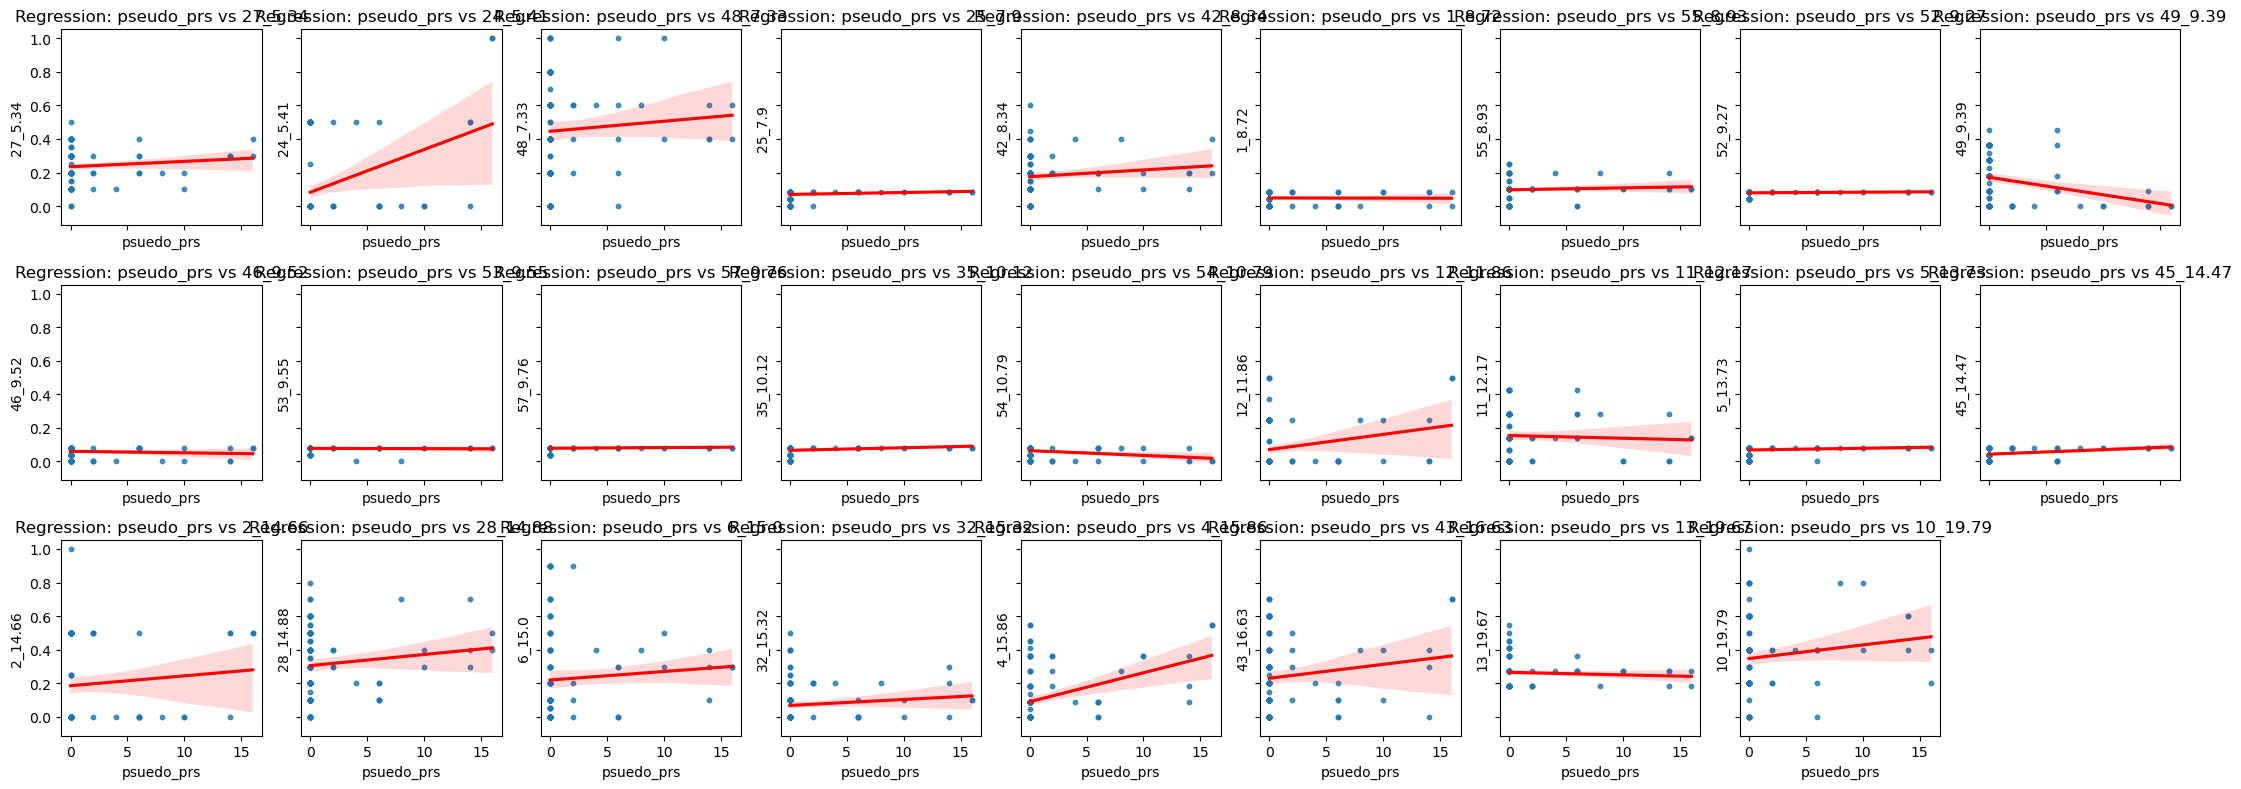

In [831]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes
fig, axes = plt.subplots(nrows=3, ncols=9, figsize=(22, 8), sharex=True, sharey=True)

# Flatten the axes array for easier iteration if it's 2D (for more than 3 plots)
axes = axes.flatten()

# Loop through the columns you want to plot against 'pseudo_prs'
for i, col in enumerate(merged_df.columns[1:]):
    # Create a regplot on the appropriate subplot
    sns.regplot(data=merged_df, x='psuedo_prs', y=col, ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})

    # Set the title to the column name for clarity
    axes[i].set_title(f'Regression: pseudo_prs vs {col}')

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused axes if there are any (in case the number of plots isn't a multiple of 3)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# Show the plot
plt.show()


In [710]:
merged_df

,psuedo_prs,27_5.34,24_5.41,48_7.33,25_7.9,42_8.34,1_8.72,55_8.93,52_9.27,49_9.39,...,5_13.73,45_14.47,2_14.66,28_14.88,6_15.0,32_15.32,4_15.86,43_16.63,13_19.67,10_19.79
bio1_ecotype,,,,,,,,,,,,,,,,,,,,,
100001_15.83,16,0.4,1.0,0.6,0.083333,0.2,0.000000,0.1,0.083333,0.000000,...,0.083333,0.083333,0.5,0.4,0.3,0.1,0.545455,0.7,0.272727,0.4
100002_15.1,0,0.5,0.0,0.6,0.083333,0.2,0.000000,0.1,0.083333,0.000000,...,0.083333,0.083333,0.5,0.5,0.2,0.1,0.545455,0.7,0.272727,0.4
10002_8.88,0,0.1,0.0,0.8,0.083333,0.2,0.083333,0.0,0.083333,0.090909,...,0.083333,0.083333,0.5,0.4,0.6,0.1,0.000000,0.3,0.272727,0.6
5784_8.4,0,0.3,0.0,0.8,0.083333,0.2,0.083333,0.1,0.083333,0.181818,...,0.083333,0.000000,0.0,0.5,0.2,0.0,0.090909,0.2,0.272727,0.4
6040_7.64,0,0.3,0.0,0.8,0.083333,0.3,0.083333,0.0,0.083333,0.363636,...,0.000000,0.000000,0.0,0.3,0.0,0.0,0.000000,0.3,0.272727,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9941_14.27,0,0.2,0.0,0.8,0.083333,0.1,0.083333,0.0,0.083333,0.000000,...,0.000000,0.000000,0.0,0.5,0.5,0.1,0.000000,0.4,0.181818,0.6
9944_17.84,14,0.3,0.5,0.4,0.083333,0.2,0.000000,0.2,0.083333,0.000000,...,0.083333,0.083333,0.0,0.7,0.3,0.3,0.363636,0.3,0.272727,0.6
9947_11.03,2,0.3,0.5,0.4,0.083333,0.2,0.083333,0.1,0.083333,0.000000,...,0.083333,0.083333,0.5,0.3,0.2,0.2,0.363636,0.3,0.181818,0.4


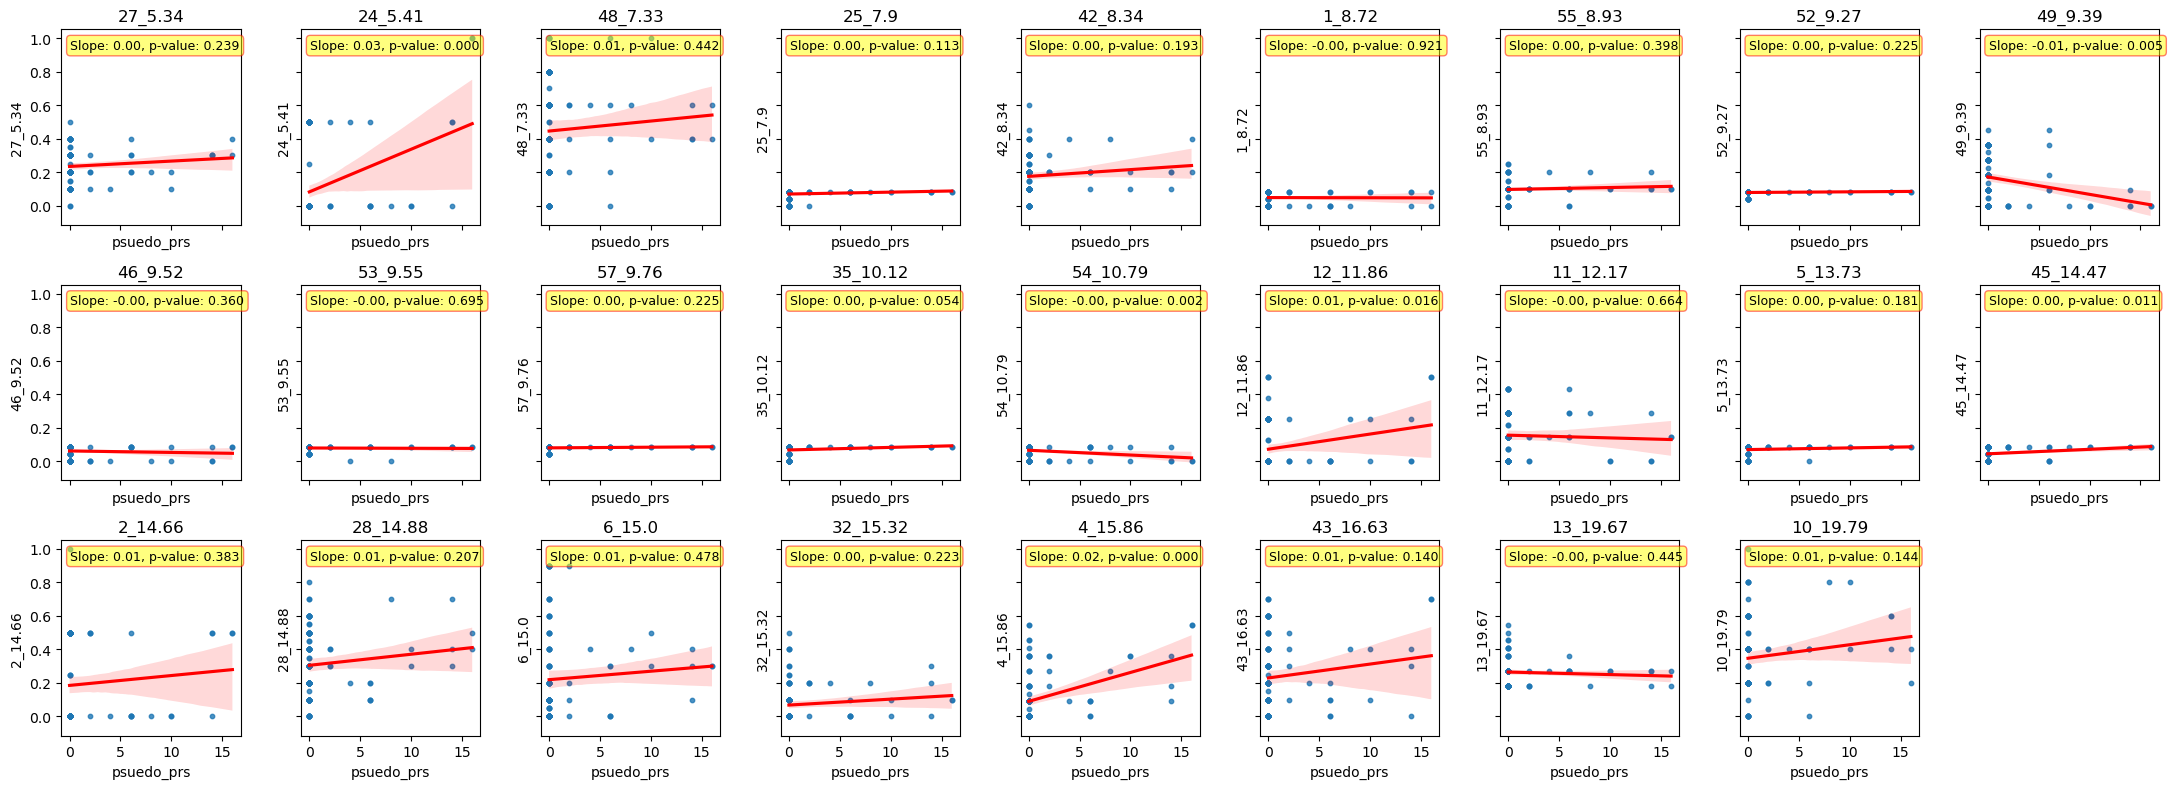

In [832]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# Set up the figure and axes
fig, axes = plt.subplots(nrows=3, ncols=9, figsize=(22, 8), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the axes array for easier iteration

# Loop through the columns you want to plot against 'pseudo_prs'
for i, col in enumerate(merged_df.columns[1:]):
    # Prepare data for regression
    x = merged_df['psuedo_prs'].values  # Predictor
    y = merged_df[col].values  # Response
    x = sm.add_constant(x)  # Adds a constant term to the predictor
    
    # Perform regression
    model = sm.OLS(y, x, missing='drop')  # OLS regression, excluding NaNs
    results = model.fit()
    
    # Extract slope and p-value
    slope = results.params[1]
    p_value = results.pvalues[1]
    
    # Create a regplot on the appropriate subplot
    sns.regplot(data=merged_df, x='psuedo_prs', y=col, ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
    
    # Annotate the plot with slope and p-value
    annotation = f'Slope: {slope:.2f}, p-value: {p_value:.3f}'
    axes[i].annotate(annotation, xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='yellow', alpha=0.5))
    
    # Set the title to the column name for clarity
    axes[i].set_title(f'{col}')

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# Show the plot
plt.show()


In [663]:
# Calculate correlation of 'pseudo_prs' with each column
correlations = merged_df.corr()#.loc['pseudo_prs'].drop('pseudo_prs')

In [665]:
correlations = correlations['psuedo_prs'].reset_index()

In [668]:
correlations = correlations.set_index('index')

<Axes: ylabel='index'>

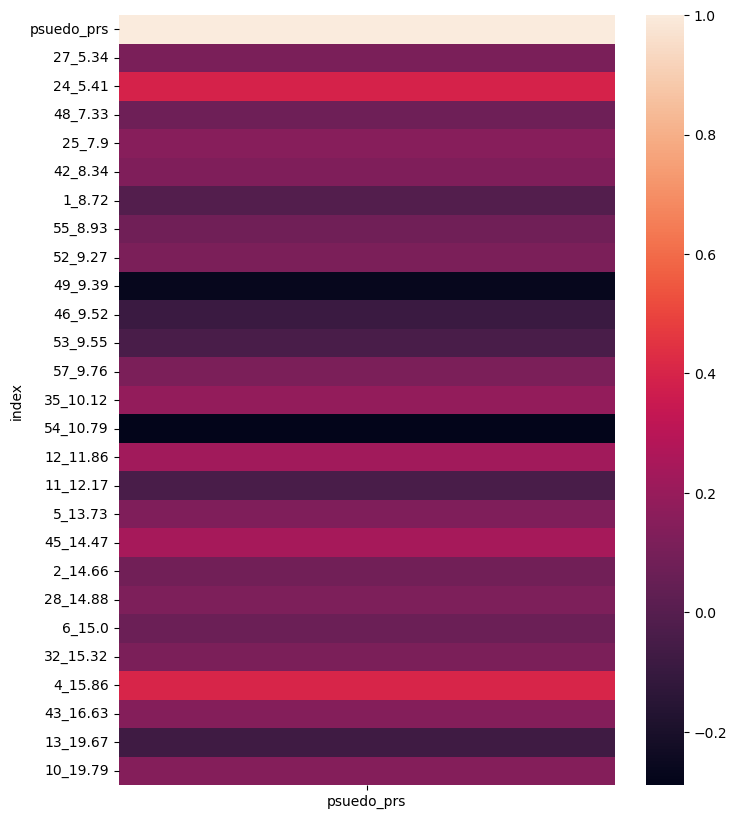

In [670]:
plt.figure(figsize=(8, 10)) 
sns.heatmap(correlations)

<Axes: xlabel='bio1_exp', ylabel='bio1_ecotype'>

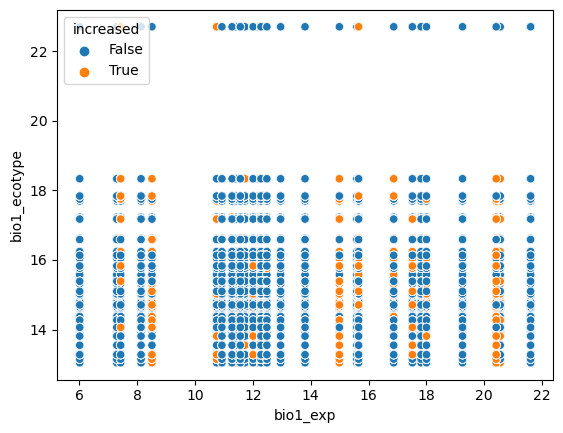

In [377]:
sns.scatterplot(result, x = 'bio1_exp', y = 'bio1_ecotype', hue = 'increased')

In [348]:
result[result['increased']==True]

,site,plot,ecotype,increased
17,1,1,9526,True
36,1,1,9759,True
78,1,10,9596,True
108,1,11,7063,True
109,1,11,7067,True
...,...,...,...,...
17993,9,7,9879,True
17995,9,7,9940,True
17997,9,7,9944,True
18031,9,8,9600,True
